The goal of this notebook is to figure out how to calculate the infall times of subhalos onto "massive progenitors" and onto the "main host"
Main goals:
* The "upid" field in Symphony should return a list of ROCKSTAR ids
* t_infall_anything_bigger = time or snapshot when the subhalo under scrutiny falls into *any* more massive object (massive progenitor or main host)
* t_infall_main_host = time when the subhalo under scrutiny falls into *specifically* the main host
* t_disrupt = time when the subhalo under scrutiny falls below the density required for ROCKSTAR to designate it a subhalo (300 particles)

Using these:
* Create probability density functions (basically histograms) where the infall times are sorted into time bins, allowing us to see if/when the distribution of infall times is peaked and how it behaves across different mass ranges. It would be good to make one version that is not normalized to host formation time, and another that is.
* Create a plot using an autocorrelation function to measure how correlated the infall times of the "massive progenitor" are with the other subhalos (both field and associated I assume? This is the one I'm less clear on). It may also be useful to have a version that shows this effect but for different lines of sight. Autocorrelation should be giving a characteristic time interval for subhalo infalls.
* Calculate the "preprocessed fraction," in other words the number of subhalos that fall onto something else before falling onto the MW, divided by the total number
* Make a plot comparing the location/slope of the SHMF (before and after a particular massive infall), and the other side showing the change in the subhalo count of the massive infalls (GSE, LMC). Would be good to put side-by-side.
* Cross-correlation function (?)

In [1]:
## packages and globals

import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import colormaps
import matplotlib.colors as mcolors

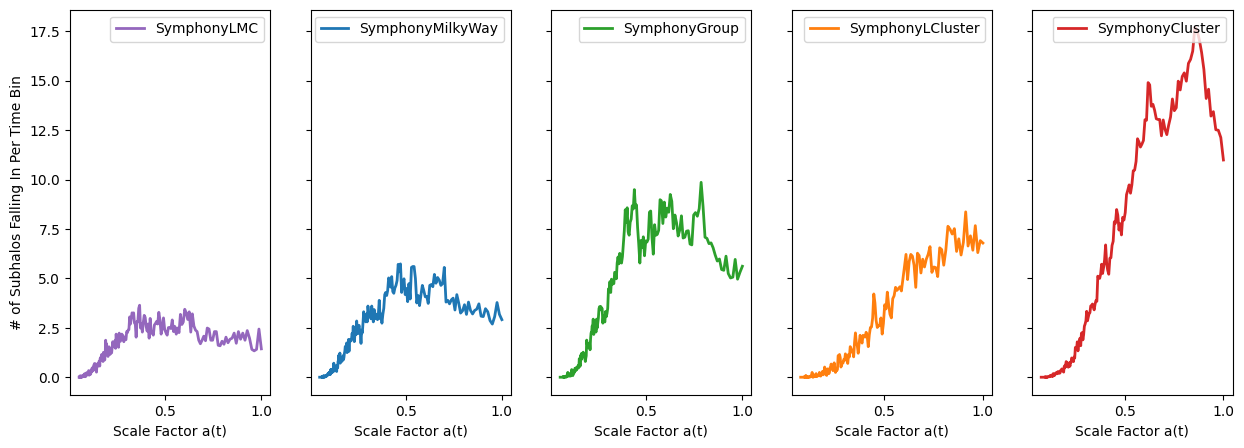

In [3]:
## defining globals:
base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

## getting id's and other thingys
fig, ax = plt.subplots(ncols = 5, nrows = 1, figsize = (15, 5), sharey = True)

for suite_index, suite in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite)

    histogram_subhalo_counts = None

    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        
        h, hist = symlib.read_subhalos(sim_dir)
        merger_snap = hist["merger_snap"]

        scale_factors = symlib.scale_factors(sim_dir)
        bins = len(scale_factors)

        if histogram_subhalo_counts is None:
            histogram_subhalo_counts = np.zeros(bins)
            
        valid_snaps = merger_snap[merger_snap > 0]  ## keeping only the snapshots excluding the MW host

        counts, _ = np.histogram(valid_snaps, bins = np.arange(bins+1))  ## counting subhalos per bin

        histogram_subhalo_counts += counts

    x = scale_factors

    ax[suite_index].plot(x, histogram_subhalo_counts / n_hosts, color = colors[suite_index], label = suite, lw = 2)
    ax[suite_index].set_xlabel("Scale Factor a(t)")
    ax[suite_index].legend()

# Shared y-label
ax[0].set_ylabel("# of Subhalos Falling In Per Time Bin")
#plt.tight_layout()
plt.savefig("infalltimes.png")
plt.show()